In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
from tqdm import tqdm
import sys
sys.path.append('..')
# from src.models import PINN
# from src.train_utils import *
from pyhessian import hessian
# from src.precond_hessian import precond_hessian

In [2]:
"""
INPUT:
- eigenvalues: eigenvalues from each run
- weights: corresponding eigenvalue weights from each run
- num_grid_points: number of points on the grid
- sigma_squared: smoothing variable (in the range of [1e-5,1e-1])
- boundary_margin: additional margin on both sides of the grid
OUTPUT:
- densities: density at each grid point
- grid_points: grid points
"""
def generate_density(eigenvalues, weights, num_grid_points=int(1e5), sigma_squared=1e-5, boundary_margin=1e-3):


  def gaussian(x, x0, variance):
    return np.exp(-(x0 - x)**2 / (2.0 * variance)) / np.sqrt(2 * np.pi * variance)

  eigenvalues = np.array(eigenvalues).real
  weights = np.array(weights).real

  num_runs, num_eigvals = eigenvalues.shape


  lambda_max = np.mean(np.max(eigenvalues, axis=1), axis=0) + boundary_margin
  lambda_min = np.mean(np.min(eigenvalues, axis=1), axis=0) - boundary_margin

  grid_points = np.linspace(lambda_min, lambda_max, num=num_grid_points)
  grid_length = (lambda_max - lambda_min) / (num_grid_points - 1)

  sigma = sigma_squared * max(1, (lambda_max - lambda_min))

  # compute density
  densities = np.zeros((num_runs, num_grid_points), dtype=eigenvalues.dtype)
  for i in range(num_runs):
    for j in range(num_grid_points):
      x = grid_points[j]
      convolutions = gaussian(eigenvalues[i,:], x, sigma)
      densities[i,j] = np.sum(convolutions * weights[i,:])

  # average across runs
  densities = np.mean(densities, axis=0)
  densities = densities / (np.sum(densities) * grid_length)

  return densities, grid_points

In [3]:
import pickle

with open('eigen_data/pinn_advection_momentum.pkl', 'rb') as f:
   results = pickle.load(f)

eigen_list_adv_pinn_momentum = results['eigen_list_full']
weight_list_adv_pinn_momentum = results['weight_list_full']

with open('eigen_data/pinn_proj_advection_momentum.pkl', 'rb') as f:
   results = pickle.load(f)

eigen_list_adv_proj_momentum = results['eigen_list_full']
weight_list_adv_proj_momentum = results['weight_list_full']

with open('eigen_data/pinn_proj_advection_energy.pkl', 'rb') as f:
   results = pickle.load(f)


eigen_list_adv_proj_energy = results['eigen_list_full']
weight_list_adv_proj_energy = results['weight_list_full']

with open('eigen_data/pinn_kdv_momentum.pkl', 'rb') as f:
   results = pickle.load(f)

eigen_list_kdv_pinn_momentum = results['eigen_list_full']
weight_list_kdv_pinn_momentum = results['weight_list_full']

with open('eigen_data/pinn_proj_kdv_momentum.pkl', 'rb') as f:
   results = pickle.load(f)

eigen_list_kdv_proj_momentum = results['eigen_list_full']
weight_list_kdv_proj_momentum = results['weight_list_full']

with open('eigen_data/pinn_proj_kdv_energy.pkl', 'rb') as f:
   results = pickle.load(f)

eigen_list_kdv_proj_energy = results['eigen_list_full']
weight_list_kdv_proj_energy = results['weight_list_full']


with open('eigen_data/pinn_wave_momentum.pkl', 'rb') as f:
   results = pickle.load(f)

eigen_list_wave_pinn_momentum = results['eigen_list_full']
weight_list_wave_pinn_momentum = results['weight_list_full']

with open('eigen_data/pinn_proj_wave_momentum.pkl', 'rb') as f:
   results = pickle.load(f)

eigen_list_wave_proj_momentum = results['eigen_list_full']
weight_list_wave_proj_momentum = results['weight_list_full']

with open('eigen_data/pinn_proj_wave_energy.pkl', 'rb') as f:
   results = pickle.load(f)

eigen_list_wave_proj_energy = results['eigen_list_full']
weight_list_wave_proj_energy = results['weight_list_full']

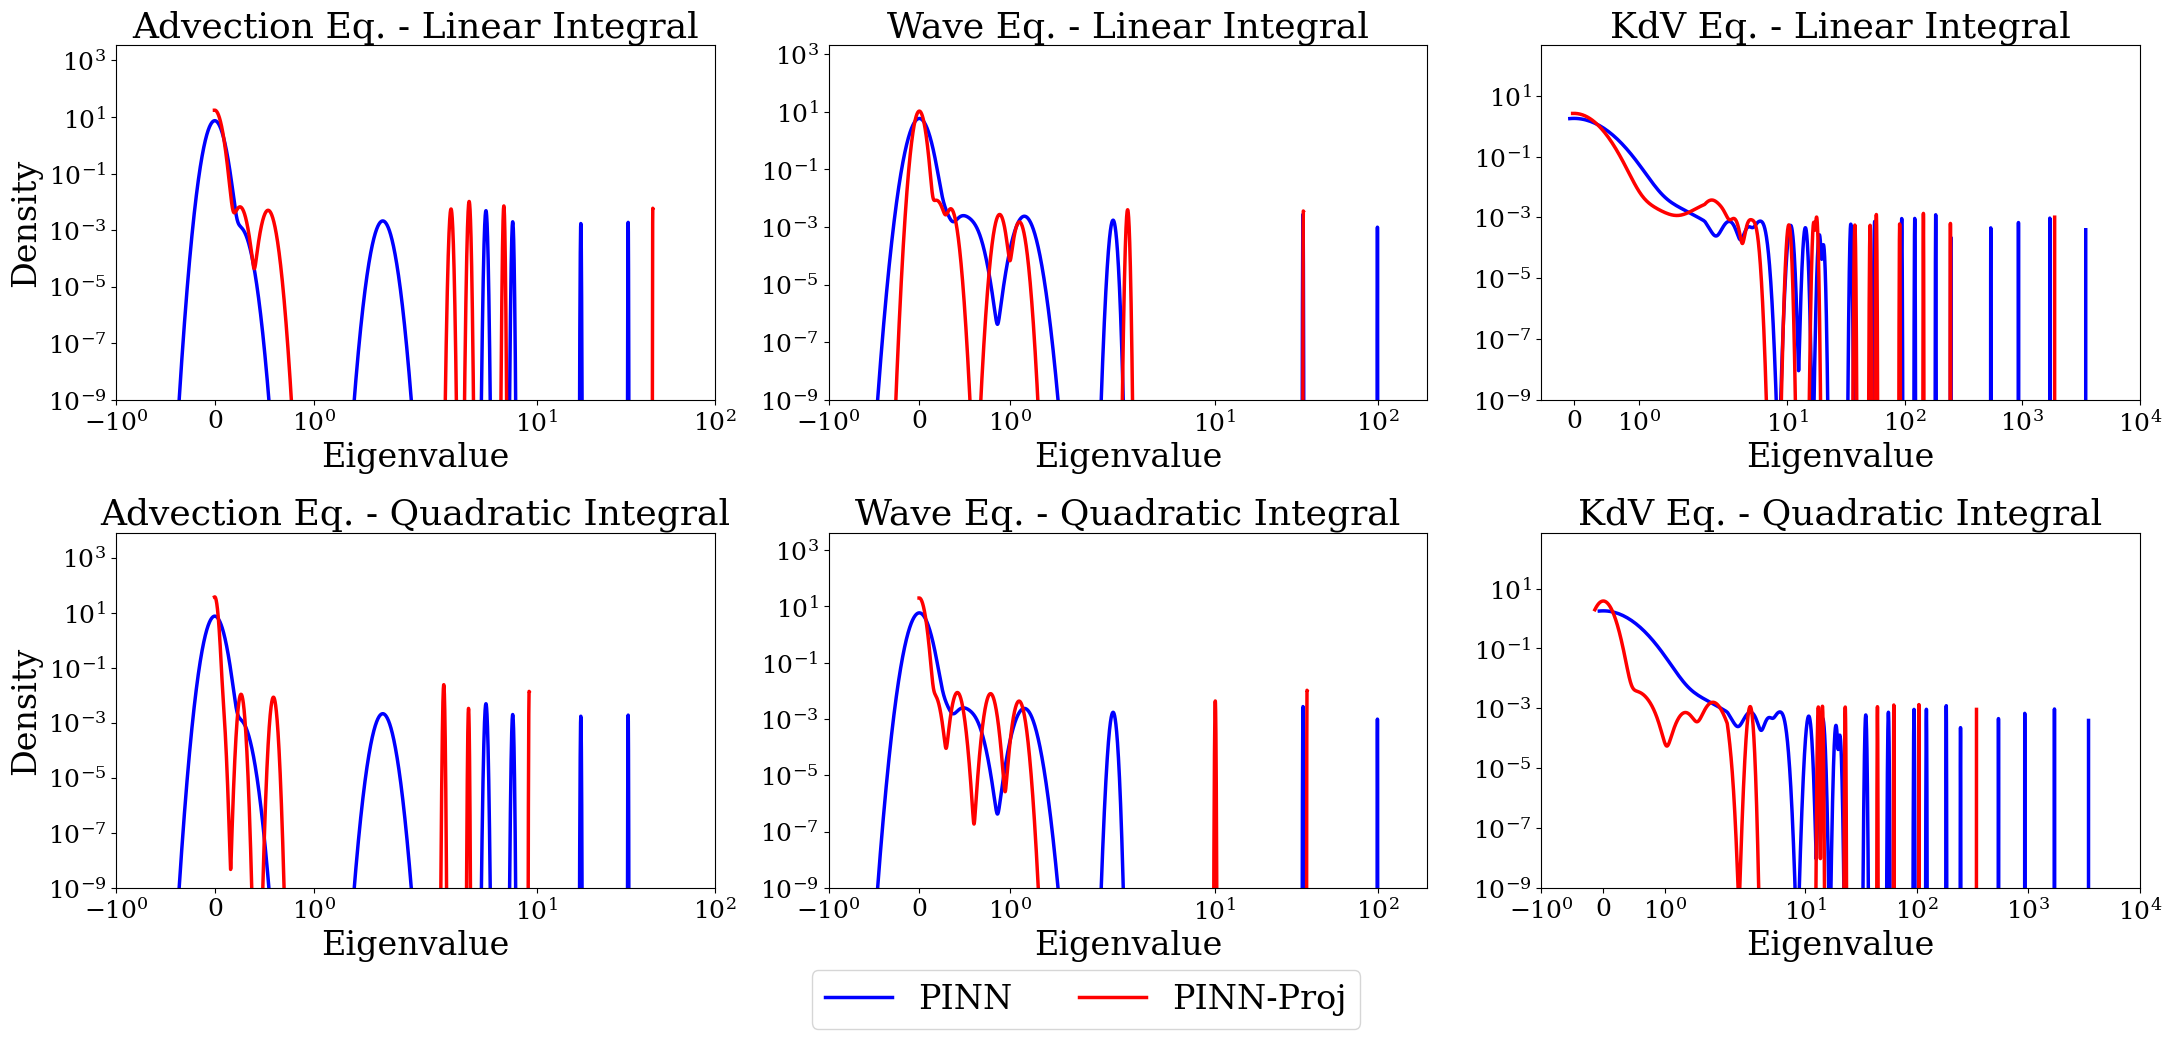

In [7]:
import matplotlib.pyplot as plt
import numpy as np


# Set up matplotlib styling to match your format
plt.rcParams.update({
    'font.size': 16,          # Default font size
    'axes.titlesize': 26,     # Title font size
    'axes.labelsize': 24,     # X and Y label font size
    'xtick.labelsize': 18,    # X tick label font size
    'ytick.labelsize': 18,    # Y tick label font size
    'legend.fontsize': 24     # Legend font size
})

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Computer Modern Roman"],
    "mathtext.fontset": "cm",  # Computer Modern for math
})

# plt.rcParams['text.usetex'] = False
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Computer Modern']

gaussian_variance = 4e-5
y_cutoff = 1e-9

# You'll need 6 different datasets - adjust these variable names as needed
datasets = [
   (eigen_list_adv_proj_momentum, weight_list_adv_proj_momentum, eigen_list_adv_pinn_momentum, weight_list_adv_pinn_momentum),
   (eigen_list_wave_proj_momentum, weight_list_wave_proj_momentum, eigen_list_wave_pinn_momentum, weight_list_wave_pinn_momentum),
   (eigen_list_kdv_proj_momentum, weight_list_kdv_proj_momentum, eigen_list_kdv_pinn_momentum, weight_list_kdv_pinn_momentum),
   (eigen_list_adv_proj_energy, weight_list_adv_proj_energy, eigen_list_adv_pinn_momentum, weight_list_adv_pinn_momentum),
   (eigen_list_wave_proj_energy, weight_list_wave_proj_energy, eigen_list_wave_pinn_momentum, weight_list_wave_pinn_momentum),
   (eigen_list_kdv_proj_energy, weight_list_kdv_proj_energy, eigen_list_kdv_pinn_momentum, weight_list_kdv_pinn_momentum),
]
# Titles for each subplot
titles = ['Advection Eq. - Linear Integral', 'Wave Eq. - Linear Integral', 'KdV Eq. - Linear Integral', 'Advection Eq. - Quadratic Integral', 'Wave Eq. - Quadratic Integral', 'KdV Eq. - Quadratic Integral']

# Define colors and styles
line_colors = {'hessian': 'blue', 'precond_hessian': 'red'}
line_styles = {'hessian': '-', 'precond_hessian': '-'}

fig, axes = plt.subplots(2, 3, figsize=(22, 10))


for i, (eigen_proj, weight_proj, eigen_pinn, weight_pinn) in enumerate(datasets):
    # Generate densities for this dataset
    hessian_densities, hessian_grid = generate_density(eigen_proj, weight_proj, sigma_squared=gaussian_variance)
    hessian_densities_pinn, hessian_grid_pinn = generate_density(eigen_pinn, weight_pinn, sigma_squared=gaussian_variance)

    row = i // 3
    col = i % 3
    ax = axes[row, col]
    # Identify first and last grid points such that the corresponding density is no smaller than the cutoff
    xlim_idx_hessian = np.argwhere(hessian_densities >= y_cutoff)[[0, -1]]
    xlim_idx_hessian_pinn = np.argwhere(hessian_densities_pinn >= y_cutoff)[[0, -1]]
    

    # Pick the overall boundary grid points
    xlim_lower = min(hessian_grid[xlim_idx_hessian[0]], hessian_grid_pinn[xlim_idx_hessian_pinn[0]]) 
    xlim_upper = max(hessian_grid[xlim_idx_hessian[1]], hessian_grid_pinn[xlim_idx_hessian_pinn[1]])
    
    # For the lower boundary, round it down to the nearest power of 10
    lower_exponent = np.floor(np.log10(np.abs(xlim_lower)))
    xlim_lower = -1 * (10 ** (lower_exponent + 1)) if xlim_lower < 0 else 10 ** lower_exponent
    if (xlim_lower <= 0) & (xlim_lower > -0.5):
        xlim_lower = -0.5  # make sure there is space if it's negative and too close to zero
    
    # For the upper boundary, round it up to the nearest integer significand
    upper_exponent = np.floor(np.log10(np.abs(xlim_upper)))
    xlim_upper = np.ceil(xlim_upper / (10 ** upper_exponent)) * (10 ** upper_exponent)
    
    # Plot the densities
    ax.semilogy(hessian_grid_pinn, hessian_densities_pinn, 
            color='b', 
            linestyle=line_styles['precond_hessian'],
            label='PINN', linewidth=2.5)
    ax.semilogy(hessian_grid, hessian_densities, 
                color='r', 
                linestyle=line_styles['hessian'],
                label='PINN-Proj', linewidth=2.5)

    
    # Set scales and limits
    ax.set_xscale('symlog')
    ax.set_ylim(bottom=y_cutoff)

    if i == 0 or i == 3:
        xlim_upper = 1e2
        x_lim_lower = -1
        ax.set_xticks([-1, 0, 1, 1e1, 1e2])
    if i == 1 or i == 4:
        # xlim_upper = 1e3
        x_lim_lower = -1
        # ax.set_xticks([0, 1, 1e1, 1e2, 1e3])
        xlim_upper = 2e2
        ax.set_xticks([-1, 0, 1, 1e1, 1e2])
    if i == 2 or i == 5:
        # xlim_lower = -10
        x_lim_lower = -1
        xlim_upper = 1e4
        ax.set_xticks([-1, 0, 1, 1e1, 1e2, 1e3, 1e4])
        # ax.set_xticks([-1e2, 0, 1e2, 1e4])

    # print(xlim_lower, xlim_upper)
    ax.set_xlim(left=xlim_lower, right=xlim_upper)
    # if abs(xlim_lower) >  abs(xlim_upper):
    #     ax.set_xlim(left=xlim_lower, right=-xlim_lower)
    # else:
    #     ax.set_xlim(left=-xlim_upper, right=xlim_upper)

    # Labels and title
    if i == 0 or i == 3:
        ax.set_ylabel('Density')
    ax.set_xlabel('Eigenvalue')
    ax.set_title(titles[i])
    
    # ax.legend()
    # ax.grid(True, alpha=0.3)

# Overall title for the figure
# Get handles and labels from just the first subplot to avoid duplicates
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=2)
plt.tight_layout()
plt.savefig('spectrum.png', dpi=300, bbox_inches='tight')
plt.show()